# Customer Complaint Classification

In this notebook, trained three text classifiers on the CFPB consumer complaints dataset.

compared Logistic Regression, Linear SVM, and Random Forest, then save the best model for inference.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings

warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

for resource in ['stopwords', 'punkt', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(resource, quiet=True)

## 1. Load Data

In [2]:
df = pd.read_csv("../Dataset/customercomplaints.csv",
                 usecols=['Consumer Complaint', 'Product'],
                 nrows=30000)

df.columns = ['Product', 'Consumer Complaint']
df = df.rename(columns={'Consumer Complaint': 'text', 'Product': 'label'})
df = df.dropna().reset_index(drop=True)

df['label'] = df['label'].astype(str).str.strip()
df['text']  = df['text'].astype(str).str.strip()

print("Shape:", df.shape)
print()
print(df['label'].value_counts())

Shape: (2114, 2)

label
Debt collection                                                                 519
Mortgage                                                                        407
Credit reporting                                                                395
Credit card                                                                     270
Bank account or service                                                         185
Student loan                                                                    145
Consumer Loan                                                                   108
Payday loan                                                                      26
Money transfers                                                                  22
Prepaid card                                                                     18
Credit reporting, credit repair services, or other personal consumer reports      9
Other financial service                             

## 2. Filter to Four Categories


In [3]:
keep = ['Credit reporting', 'Debt collection', 'Mortgage', 'Credit card']
df   = df[df['label'].isin(keep)].reset_index(drop=True)

df['label'] = df['label'].astype(str)
df['text']  = df['text'].astype(str)

print("Shape after filtering:", df.shape)
print()
print(df['label'].value_counts())

Shape after filtering: (1591, 2)

label
Debt collection     519
Mortgage            407
Credit reporting    395
Credit card         270
Name: count, dtype: int64


## 3. Exploratory Data Analysis

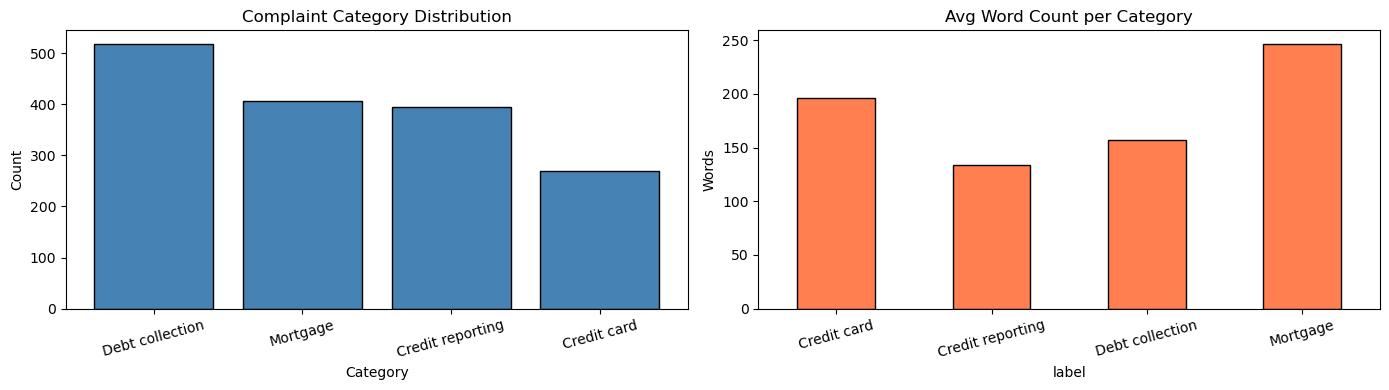


Basic stats:
count    1591.000000
mean      180.683847
std       163.683146
min         5.000000
25%        68.000000
50%       122.000000
75%       231.500000
max       791.000000
Name: word_count, dtype: float64


In [4]:
# class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Complaint Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# avg word count per category
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df.groupby('label')['word_count'].mean().plot(kind='bar', color='coral',
                                               edgecolor='black', ax=axes[1])
axes[1].set_title('Avg Word Count per Category')
axes[1].set_ylabel('Words')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nBasic stats:")
print(df['word_count'].describe())

In [5]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dedup:", df.shape)

Missing values:
label         0
text          0
word_count    0
dtype: int64

Duplicate rows: 4
Shape after dedup: (1587, 3)


## 4. Text Preprocessing

Cleaning steps applied:
lowercase conversion, URL and placeholder removal (`XXXX` tokens), digit and punctuation stripping, stopword removal, lemmatization

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'\bxx+\b', '', text)            # XXXX tokens
    text = re.sub(r'\d+', '', text)                # digits
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['text'].apply(clean_text)

print("Before:", df['text'][0][:120])
print("\nAfter :", df['cleaned'][0][:120])

Before: I have outdated information on my credit report that I have previously disputed that has yet to be removed this informat

After : i have outdated information on my credit report that i have previously disputed that has yet to be removed this informat


In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

df['final_text'] = df['cleaned'].apply(preprocess)

print("Cleaned  :", df['cleaned'][0][:120])
print("\nProcessed:", df['final_text'][0][:120])

Cleaned  : i have outdated information on my credit report that i have previously disputed that has yet to be removed this informat

Processed: outdated information credit report previously disputed yet removed information seven year old meet credit reporting requ


In [8]:
df[['text', 'cleaned', 'final_text']].head()

,text,cleaned,final_text
0,I have outdated information on my credit repor...,i have outdated information on my credit repor...,outdated information credit report previously ...
1,An account on my credit report has a mistaken ...,an account on my credit report has a mistaken ...,account credit report mistaken date mailed deb...
2,This company refuses to provide me verificatio...,this company refuses to provide me verificatio...,company refuse provide verification validation...
3,This complaint is in regards to Square Two Fin...,this complaint is in regards to square two fin...,complaint regard square two financial refer cf...
4,Started the refinance of home mortgage process...,started the refinance of home mortgage process...,started refinance home mortgage process cash o...


## 5. Feature Engineering — TF-IDF

In [9]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("Classes :", list(le.classes_))
print("Encoded :", list(le.transform(le.classes_)))

Classes : ['Credit card', 'Credit reporting', 'Debt collection', 'Mortgage']
Encoded : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [10]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    sublinear_tf=True     # log(tf) smoothing
)

X = tfidf.fit_transform(df['final_text'])
y = df['label_encoded']

print("Feature matrix:", X.shape)
print("Classes       :", len(le.classes_))

Feature matrix: (1587, 5000)
Classes       : 4


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 1269  |  Test: 318


## 6. Model Training

In [12]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=300, C=1.0)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
print(f"  Accuracy: {lr_acc*100:.2f}%")

Training Logistic Regression...
  Accuracy: 89.31%


In [13]:
print("Training Linear SVM...")
svm = LinearSVC(C=1.0, max_iter=1000)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
svm_acc   = accuracy_score(y_test, svm_preds)
print(f"  Accuracy: {svm_acc*100:.2f}%")

Training Linear SVM...
  Accuracy: 88.36%


In [14]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
print(f"  Accuracy: {rf_acc*100:.2f}%")

Training Random Forest...
  Accuracy: 84.59%


## 7. Evaluation & Comparison

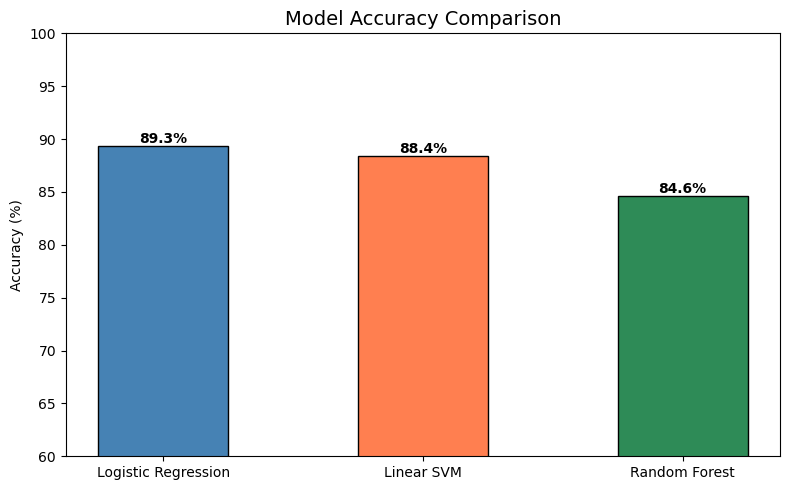

In [15]:
model_names = ['Logistic Regression', 'Linear SVM', 'Random Forest']
accuracies  = [lr_acc*100, svm_acc*100, rf_acc*100]
colors      = ['steelblue', 'coral', 'seagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(60, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{acc:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
best_name, best_preds, best_acc = max(
    [('Logistic Regression', lr_preds, lr_acc),
     ('Linear SVM',          svm_preds, svm_acc),
     ('Random Forest',       rf_preds, rf_acc)],
    key=lambda x: x[2]
)

print(f"Best model: {best_name}  ({best_acc*100:.2f}%)")
print()
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, best_preds, target_names=le.classes_))

Best model: Logistic Regression  (89.31%)

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Credit card       0.92      0.83      0.87        54
Credit reporting       0.84      0.92      0.88        78
 Debt collection       0.92      0.85      0.88       104
        Mortgage       0.91      0.96      0.93        82

        accuracy                           0.89       318
       macro avg       0.90      0.89      0.89       318
    weighted avg       0.90      0.89      0.89       318



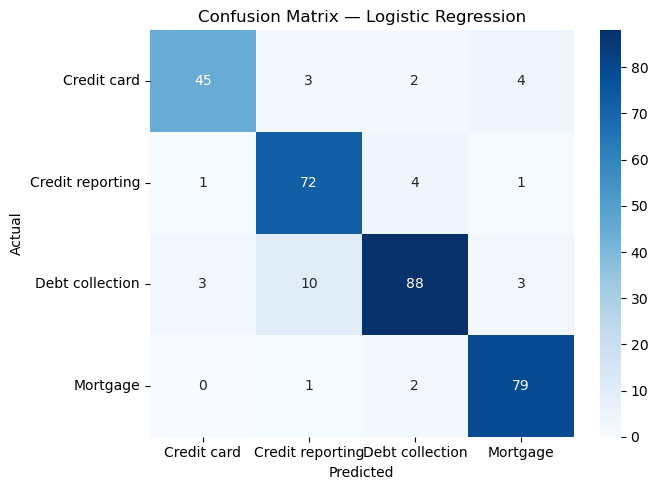

In [17]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Save Models

In [18]:
joblib.dump(lr,    "../Models/logistic_regression.pkl")
joblib.dump(svm,   "../Models/linear_svm.pkl")
joblib.dump(rf,    "../Models/random_forest.pkl")
joblib.dump(tfidf, "../Models/tfidf_vectorizer.pkl")
joblib.dump(le,    "../Models/label_encoder.pkl")

print("Models saved to Models/")

Models saved to Models/
